# Ensemble Evaluation Summary

This notebook compares several ensemble strategies for **spinal canal stenosis** classification using four base models: **Swin-S**, **ResNet34**, **EfficientNet-B0**, and **ConvNeXt-Base**. The validation set is used to configure ensemble methods, and the held-out test set is used for final evaluation.

- **Simple Probability Average:** averages the predicted class probabilities from all four models with equal weights.

- **Validation-Optimized Weighted Average:** learns non-negative model weights on the validation set by minimizing weighted log loss.

- **Logistic Regression Stacking:** trains a multinomial logistic regression model on validation-set model probabilities and applies it to the test set.

- **Shallow Decision Tree Stacking:** trains a shallow decision tree on validation-set model probabilities to create an interpretable rule-based meta-classifier.

- **Safety-Net Max-Severity Ensemble:** predicts the worst severity suggested by any model, prioritizing detection of `Moderate` or `Severe` cases.

Evaluation focuses on accuracy, weighted log loss, macro AUC, `Moderate`/`Severe` recall, positive diagnosis recall, missed positives, and false alarms.

In [1]:
# CONDITION
CONDITION_KEY = "subarticular_stenosis"
BASE_CONDITION = "Subarticular Stenosis"
SERIES_DESCRIPTION = "Axial T2"


In [2]:
# CONDITION-SPECIFIC CLASSIFIERS

MODEL_CONFIGS = {
    "spinal_canal_stenosis": {
        "base_condition": "Spinal Canal Stenosis",
        "series_description": "Sagittal T2/STIR",
    },
    "neural_foraminal_narrowing": {
        "base_condition": "Neural Foraminal Narrowing",
        "series_description": "Sagittal T1",
    },
    "subarticular_stenosis": {
        "base_condition": "Subarticular Stenosis",
        "series_description": "Axial T2",
    },
}


In [3]:
# MODEL CHECKPOINTS — current project structure

from pathlib import Path

ROOT = Path("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification")
MODEL_ROOT = ROOT / "Classification-baseline" / "models"

MODEL_SPECS = {
    "resnet34": {
        "backbone": "resnet34",
        "checkpoint": MODEL_ROOT / "models_classification_ResNet34_96_zoom_resnet34" / f"{CONDITION_KEY}_best.pt",
    },
    "efficientnet_b0": {
        "backbone": "efficientnet_b0",
        "checkpoint": MODEL_ROOT / "models_classification_EfficientNet_b_96_zoom_efficientnet_b0" / f"{CONDITION_KEY}_best.pt",
    },
    "densenet169": {
        "backbone": "densenet169",
        "checkpoint": MODEL_ROOT / "models_classification_densenet169_densenet169" / f"{CONDITION_KEY}_best.pt",
    },
    "convnext_base": {
        "backbone": "convnext_base",
        "checkpoint": MODEL_ROOT / "models_classification_ConvNext_base_convnext_base" / f"{CONDITION_KEY}_best.pt",
    },
    "swin_b": {
        "backbone": "swin_b",
        "checkpoint": MODEL_ROOT / "models_classification_Swin_b_96_zoom_swin_b" / f"{CONDITION_KEY}_best.pt",
    },
}


## 1. Imports and configuration

In [4]:
# ============================================================
# BASIC IMPORTS AND CONFIGURATION
# ============================================================

from pathlib import Path
import os
import gc
import warnings

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import transforms

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    log_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore")

ROOT = Path("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification")
DATA_ROOT = ROOT / "BC-data"
PROJECT_ROOT = ROOT / "Classification-baseline"
DATA_CSV = DATA_ROOT / "data-rsna2024" / "data_merged.csv"
MODEL_ROOT = PROJECT_ROOT / "models"

os.chdir(ROOT)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# Data settings: same as the training workflow
# ------------------------------------------------------------
IMAGE_SIZE = 224
BATCH_SIZE = 64

ROI_CROP_ENABLED = True
ROI_CROP_SIZE = 96
ROI_FALLBACK_TO_FULL_IMAGE = True
X_COLUMN = None
Y_COLUMN = None

USE_2_5D_INPUT = True
SLICE_CONTEXT_OFFSETS = (-1, 0, 1)
SERIES_GROUP_COLUMNS = None
SLICE_ORDER_COLUMN = None

NUM_WORKERS = 4
PIN_MEMORY = True
PERSISTENT_WORKERS = True
PREFETCH_FACTOR = 2

# ------------------------------------------------------------
# Model-head settings used by build_metadata_classifier(...)
# ------------------------------------------------------------
PRETRAINED = True
HIDDEN_DIM = 512
DROPOUT = 0.15

print("Device:", DEVICE)
print("Project root:", PROJECT_ROOT)
print("Data CSV:", DATA_CSV)
print("Model root:", MODEL_ROOT)


Device: cuda
Project root: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Classification-baseline
Data CSV: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data/data-rsna2024/data_merged.csv
Model root: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Classification-baseline/models


## 2. Labels and condition definitions

In [5]:
# ============================================================
# LABEL DEFINITIONS
# ============================================================

SEVERITY_MAP = {
    "Normal/Mild": 0,
    "Moderate": 1,
    "Severe": 2,
}

TARGET_NAMES = ["Normal/Mild", "Moderate", "Severe"]
N_CLASSES = len(TARGET_NAMES)

LEVELS = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]

SIDE_TO_ID = {
    "center": 0,
    "left": 1,
    "right": 2,
}

SERIES_TO_ID = {
    "Sagittal T2/STIR": 0,
    "Sagittal T1": 1,
    "Axial T2": 2,
}

LEVEL_TO_ID = {level: idx for idx, level in enumerate(LEVELS)}

# Only the selected condition is used for mean/std and ensemble evaluation.
MODELS_TO_TRAIN = [CONDITION_KEY]


## 3. Load support functions

In [6]:
# ============================================================
# LOAD SUPPORT FUNCTIONS
# ============================================================
# ============================================================
# TRAINING CONFIGURATION
# ============================================================
# This cell controls loss construction, optimizer/scheduler behavior,
# checkpoint selection, and early stopping.

# ----------------------------
# Epochs and early stopping
# ----------------------------
EPOCHS = 30
MIN_EPOCHS = 8
PATIENCE = 5
MIN_DELTA = 1e-4

# ----------------------------
# Loss configuration
# ----------------------------
#   "weighted_cross_entropy"  -> inverse-frequency class weights + medical multipliers
#   "cross_entropy"           -> unweighted cross entropy
LOSS_NAME = "weighted_cross_entropy"

# Small label smoothing helps reduce overconfident validation loss explosion.
LABEL_SMOOTHING = 0.03

# Class imbalance and medical-priority controls.
# class 0 = Normal/Mild, class 1 = Moderate, class 2 = Severe.
MODERATE_WEIGHT_MULTIPLIER = 1.0
SEVERE_WEIGHT_MULTIPLIER = 1.1

# Keep sampler off when using class-weighted loss.
USE_WEIGHTED_SAMPLER = False

# ----------------------------
# Optimizer configuration
# ----------------------------
OPTIMIZER_NAME = "adamw"

# Slightly lower LR because ROI/2.5D model appears to overfit very fast.
LR = 1e-5

# Keep pretrained backbone updates small.
BACKBONE_LR_MULTIPLIER = 0.1

# Stronger weight decay for regularization.
WEIGHT_DECAY = 1e-3

GRAD_CLIP_NORM = 1.0

# ----------------------------
# Scheduler configuration
# ----------------------------
# For ReduceLROnPlateau, SCHEDULER_MONITOR must be one key from val_metrics,
# e.g. "loss", "log_loss", "macro_f1", "balanced_accuracy".
SCHEDULER_NAME = "reduce_lr_on_plateau"

# I would monitor early-stop score or macro_f1 if your training loop supports it.
SCHEDULER_MONITOR = "macro_f1"

SCHEDULER_CONFIG = {
    "mode": "max",
    "factor": 0.5,
    "patience": 2,
}

# ----------------------------
# Checkpoint and early-stopping scoring
# ----------------------------
# Less recall-only pressure. This still rewards severe recall,
# but severe F1 and general class balance matter equally.
CHECKPOINT_SCORE_WEIGHTS = {
    "severe_recall": 0.25,
    "severe_f1": 0.30,
    "pathological_f1": 0.20,
    "macro_f1": 0.15,
    "balanced_accuracy": 0.10,
}

# Early stopping should track broad validation generalization.
EARLY_STOP_SCORE_WEIGHTS = {
    "macro_f1": 0.40,
    "balanced_accuracy": 0.40,
    "pathological_f1": 0.20,
}



In [7]:
MODEL_NAMES = [
    "resnet34",
    "efficientnet_b0",
    "densenet169",
    "convnext_base",
    "swin_b",
]
%run ./Classification-baseline/100_class_support_functions.ipynb
set_seed(42)

## 4. Load data and recreate the existing train / validation / test split

In [8]:
# ============================================================
# LOAD AND PREPARE DATAFRAME
# ============================================================

data_merged = pd.read_csv(DATA_CSV)

data_merged["side"] = data_merged["condition"].apply(extract_side)
data_merged["base_condition"] = data_merged["condition"].apply(extract_base_condition)
data_merged["target"] = data_merged["severity"].map(SEVERITY_MAP)

# Infer ROI coordinate columns.
if ROI_CROP_ENABLED:
    inferred_x_col, inferred_y_col = infer_coordinate_columns(data_merged)

    if X_COLUMN is None:
        X_COLUMN = inferred_x_col
    if Y_COLUMN is None:
        Y_COLUMN = inferred_y_col

    print("ROI cropping enabled:", ROI_CROP_ENABLED)
    print("ROI x column:", X_COLUMN)
    print("ROI y column:", Y_COLUMN)

    if X_COLUMN is None or Y_COLUMN is None:
        print("WARNING: Coordinate columns were not found. The dataset will fall back to full images.")
    else:
        data_merged[X_COLUMN] = pd.to_numeric(data_merged[X_COLUMN], errors="coerce")
        data_merged[Y_COLUMN] = pd.to_numeric(data_merged[Y_COLUMN], errors="coerce")

# Infer 2.5D series grouping and slice ordering.
if USE_2_5D_INPUT:
    if SERIES_GROUP_COLUMNS is None:
        SERIES_GROUP_COLUMNS = infer_series_group_columns(data_merged)

    if SLICE_ORDER_COLUMN is None:
        SLICE_ORDER_COLUMN = infer_slice_order_column(data_merged)

    if SLICE_ORDER_COLUMN is None:
        SLICE_ORDER_COLUMN = "_slice_order_from_path"
        data_merged[SLICE_ORDER_COLUMN] = data_merged["img_path"].apply(parse_slice_order_from_path)

    print("2.5D input enabled:", USE_2_5D_INPUT)
    print("Series group columns:", SERIES_GROUP_COLUMNS)
    print("Slice order column:", SLICE_ORDER_COLUMN)

    if SERIES_GROUP_COLUMNS == ["study_id", "series_description"]:
        print(
            "WARNING: No explicit series_id column was found. "
            "Using study_id + series_description as a fallback for neighbouring slices."
        )

# Required columns.
data_merged = data_merged.dropna(
    subset=[
        "study_id",
        "img_path",
        "target",
        "level",
        "side",
        "series_description",
    ]
).copy()

if USE_2_5D_INPUT:
    data_merged[SLICE_ORDER_COLUMN] = pd.to_numeric(
        data_merged[SLICE_ORDER_COLUMN],
        errors="coerce",
    )

data_merged["target"] = data_merged["target"].astype(int)

print("Base-condition counts:")
print(data_merged["base_condition"].value_counts())
print("\nSeries-description counts:")
print(data_merged["series_description"].value_counts())


ROI cropping enabled: True
ROI x column: x
ROI y column: y
2.5D input enabled: True
Series group columns: ['study_id', 'series_id']
Slice order column: instance_number
Base-condition counts:
base_condition
Neural Foraminal Narrowing    19689
Subarticular Stenosis         19215
Spinal Canal Stenosis          9738
Name: count, dtype: int64

Series-description counts:
series_description
Sagittal T1         19694
Axial T2            19215
Sagittal T2/STIR     9733
Name: count, dtype: int64


In [9]:
# ============================================================
# STUDY-LEVEL TRAIN / VALIDATION / TEST SPLIT
# ============================================================
# Same split logic as the training workflow.

TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
RANDOM_STATE = 42

# First split: train vs temporary validation + test.
gss1 = GroupShuffleSplit(
    n_splits=1,
    train_size=TRAIN_SIZE,
    random_state=RANDOM_STATE,
)

train_idx, temp_idx = next(
    gss1.split(
        data_merged,
        groups=data_merged["study_id"],
    )
)

train_df = data_merged.iloc[train_idx].copy()
temp_df = data_merged.iloc[temp_idx].copy()

# Second split: validation vs test from the temporary set.
val_relative_size = VAL_SIZE / (VAL_SIZE + TEST_SIZE)

gss2 = GroupShuffleSplit(
    n_splits=1,
    train_size=val_relative_size,
    random_state=RANDOM_STATE,
)

val_idx, test_idx = next(
    gss2.split(
        temp_df,
        groups=temp_df["study_id"],
    )
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print("Rows:")
print("train:", train_df.shape)
print("val:  ", val_df.shape)
print("test: ", test_df.shape)

print("\nUnique studies:")
print("train:", train_df["study_id"].nunique())
print("val:  ", val_df["study_id"].nunique())
print("test: ", test_df["study_id"].nunique())


Rows:
train: (34033, 18)
val:   (7288, 18)
test:  (7321, 18)

Unique studies:
train: 1381
val:   296
test:  297


## 5. Build condition-specific train / validation / test tables

In [10]:
# ============================================================
# CONDITION-SPECIFIC DATAFRAMES
# ============================================================

cfg = MODEL_CONFIGS[CONDITION_KEY]

train_part = make_model_df(
    train_df,
    base_condition=cfg["base_condition"],
    series_description=cfg["series_description"],
)

val_part = make_model_df(
    val_df,
    base_condition=cfg["base_condition"],
    series_description=cfg["series_description"],
)

test_part = make_model_df(
    test_df,
    base_condition=cfg["base_condition"],
    series_description=cfg["series_description"],
)

print("Condition:", CONDITION_KEY)
for split_name, split_df in [("train", train_part), ("val", val_part), ("test", test_part)]:
    print(f"\n{split_name}: {len(split_df):6d} rows | {split_df['study_id'].nunique():4d} studies")
    print(split_df["target"].value_counts().sort_index().rename(index=dict(enumerate(TARGET_NAMES))))


Condition: subarticular_stenosis

train:  13441 rows | 1381 studies
target
Normal/Mild    9601
Moderate       2549
Severe         1291
Name: count, dtype: int64

val:   2872 rows |  296 studies
target
Normal/Mild    2028
Moderate        570
Severe          274
Name: count, dtype: int64

test:   2902 rows |  297 studies
target
Normal/Mild    2090
Moderate        540
Severe          272
Name: count, dtype: int64


## 6. Mean/std and deterministic transforms

In [11]:
# ============================================================
# MEAN / STD FROM THE SELECTED CONDITION TRAINING SET ONLY
# ============================================================
# No files are saved in this notebook.

mean, std = compute_mean_std(
    train_part,
    batch_size=32,
    num_workers=NUM_WORKERS,
)

print("Computed mean:", mean)
print("Computed std: ", std)

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

test_transform = val_transform


Computing mean/std:   0%|          | 0/421 [00:00<?, ?it/s]

Computed mean: [0.26983046531677246, 0.2691092789173126, 0.2739189565181732]
Computed std:  [0.2362477332353592, 0.23773151636123657, 0.23905281722545624]


## 7. Model checkpoints

In [12]:
for model_name, spec in MODEL_SPECS.items():
    print(model_name)
    print("  backbone:  ", spec["backbone"])
    print("  checkpoint:", spec["checkpoint"])
    print("  exists:    ", spec["checkpoint"].exists())

resnet34
  backbone:   resnet34
  checkpoint: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Classification-baseline/models/models_classification_ResNet34_96_zoom_resnet34/subarticular_stenosis_best.pt
  exists:     True
efficientnet_b0
  backbone:   efficientnet_b0
  checkpoint: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Classification-baseline/models/models_classification_EfficientNet_b_96_zoom_efficientnet_b0/subarticular_stenosis_best.pt
  exists:     True
densenet169
  backbone:   densenet169
  checkpoint: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Classification-baseline/models/models_classification_densenet169_densenet169/subarticular_stenosis_best.pt
  exists:     True
convnext_base
  backbone:   convnext_base
  checkpoint: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Classification-baseline/models/mode

## 8. Prediction and evaluation helper functions

In [13]:

CLASS_WEIGHT_MAP = {
    0: 1.0,  # Normal/Mild
    1: 2.0,  # Moderate
    2: 4.0,  # Severe
}



## 9. Create validation and test loaders

In [14]:
# ============================================================
# VALIDATION AND TEST LOADERS
# ============================================================

val_dataset, val_loader = make_eval_loader(val_part, val_transform, batch_size=BATCH_SIZE)
test_dataset, test_loader = make_eval_loader(test_part, test_transform, batch_size=BATCH_SIZE)

print("Validation rows:", len(val_dataset), "| batches:", len(val_loader))
print("Test rows:      ", len(test_dataset), "| batches:", len(test_loader))


Validation rows: 2872 | batches: 45
Test rows:       2902 | batches: 46


## 10. Predict validation and test probabilities with every model

In [15]:
# ============================================================
# PREDICTIONS FOR VALIDATION AND TEST SETS
# ============================================================
# No CSVs are saved. Everything stays in memory.

val_pred_df = val_part.reset_index(drop=True).copy()
test_pred_df = test_part.reset_index(drop=True).copy()

val_y_reference = None
test_y_reference = None

for model_name, spec in MODEL_SPECS.items():

    model = load_checkpoint_model(
        backbone_name=spec["backbone"],
        checkpoint_path=spec["checkpoint"],
    )

    # Validation predictions.
    val_probs, val_preds, val_y = predict_proba(model, val_loader, DEVICE)
    if val_y_reference is None:
        val_y_reference = val_y
    else:
        assert np.array_equal(val_y_reference, val_y), "Validation label order mismatch."

    val_pred_df[f"{model_name}_p0"] = val_probs[:, 0]
    val_pred_df[f"{model_name}_p1"] = val_probs[:, 1]
    val_pred_df[f"{model_name}_p2"] = val_probs[:, 2]
    val_pred_df[f"{model_name}_pred"] = val_preds

    # Test predictions.
    test_probs, test_preds, test_y = predict_proba(model, test_loader, DEVICE)
    if test_y_reference is None:
        test_y_reference = test_y
    else:
        assert np.array_equal(test_y_reference, test_y), "Test label order mismatch."

    test_pred_df[f"{model_name}_p0"] = test_probs[:, 0]
    test_pred_df[f"{model_name}_p1"] = test_probs[:, 1]
    test_pred_df[f"{model_name}_p2"] = test_probs[:, 2]
    test_pred_df[f"{model_name}_pred"] = test_preds

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

val_pred_df["y_true"] = val_y_reference
test_pred_df["y_true"] = test_y_reference

#print("\nValidation prediction table:", val_pred_df.shape)
#print("Test prediction table:      ", test_pred_df.shape)
display(val_pred_df.head(3))
display(test_pred_df.head(3))


,row_id,study_id,series_id,condition,level,series_description,instance_number,x,y,severity,...,densenet169_pred,convnext_base_p0,convnext_base_p1,convnext_base_p2,convnext_base_pred,swin_b_p0,swin_b_p1,swin_b_p2,swin_b_pred,y_true
0,44060036_left_subarticular_stenosis_l3_l4,44060036,2320605986,Left Subarticular Stenosis,L3/L4,Axial T2,4,337.646566,322.680067,Normal/Mild,...,0,0.031891,0.622127,0.345982,1,0.029055,0.794274,0.176671,1,0
1,44060036_right_subarticular_stenosis_l3_l4,44060036,2320605986,Right Subarticular Stenosis,L3/L4,Axial T2,4,296.666641,319.578791,Moderate,...,1,0.074817,0.662401,0.262782,1,0.109772,0.795162,0.095066,1,1
2,44060036_left_subarticular_stenosis_l4_l5,44060036,2320605986,Left Subarticular Stenosis,L4/L5,Axial T2,8,333.358459,323.752094,Normal/Mild,...,1,0.396604,0.469521,0.133875,1,0.103364,0.835813,0.060823,1,0


,row_id,study_id,series_id,condition,level,series_description,instance_number,x,y,severity,...,densenet169_pred,convnext_base_p0,convnext_base_p1,convnext_base_p2,convnext_base_pred,swin_b_p0,swin_b_p1,swin_b_p2,swin_b_pred,y_true
0,7143189_left_subarticular_stenosis_l1_l2,7143189,1951927562,Left Subarticular Stenosis,L1/L2,Axial T2,1,212.729204,208.141593,Normal/Mild,...,0,0.916012,0.025406,0.058582,0,0.891400,0.031822,0.076778,0,0
1,7143189_right_subarticular_stenosis_l1_l2,7143189,1951927562,Right Subarticular Stenosis,L1/L2,Axial T2,2,175.315352,210.753488,Normal/Mild,...,0,0.907445,0.041246,0.051309,0,0.862459,0.063571,0.073969,0,0
2,7143189_left_subarticular_stenosis_l2_l3,7143189,1951927562,Left Subarticular Stenosis,L2/L3,Axial T2,6,210.690265,200.665487,Normal/Mild,...,0,0.688125,0.256547,0.055328,0,0.659889,0.280728,0.059383,0,0


## 11. Individual model evaluation on the test set


Evaluation: resnet34


split,n_samples,accuracy,log_loss,macro_auc_ovr,moderate_recall,severe_recall,positive_diagnosis_recall
validation,2872,0.7556,0.5943,0.8833,0.5772,0.6606,0.8270
test,2902,0.7478,0.6048,0.8772,0.5444,0.6360,0.8473


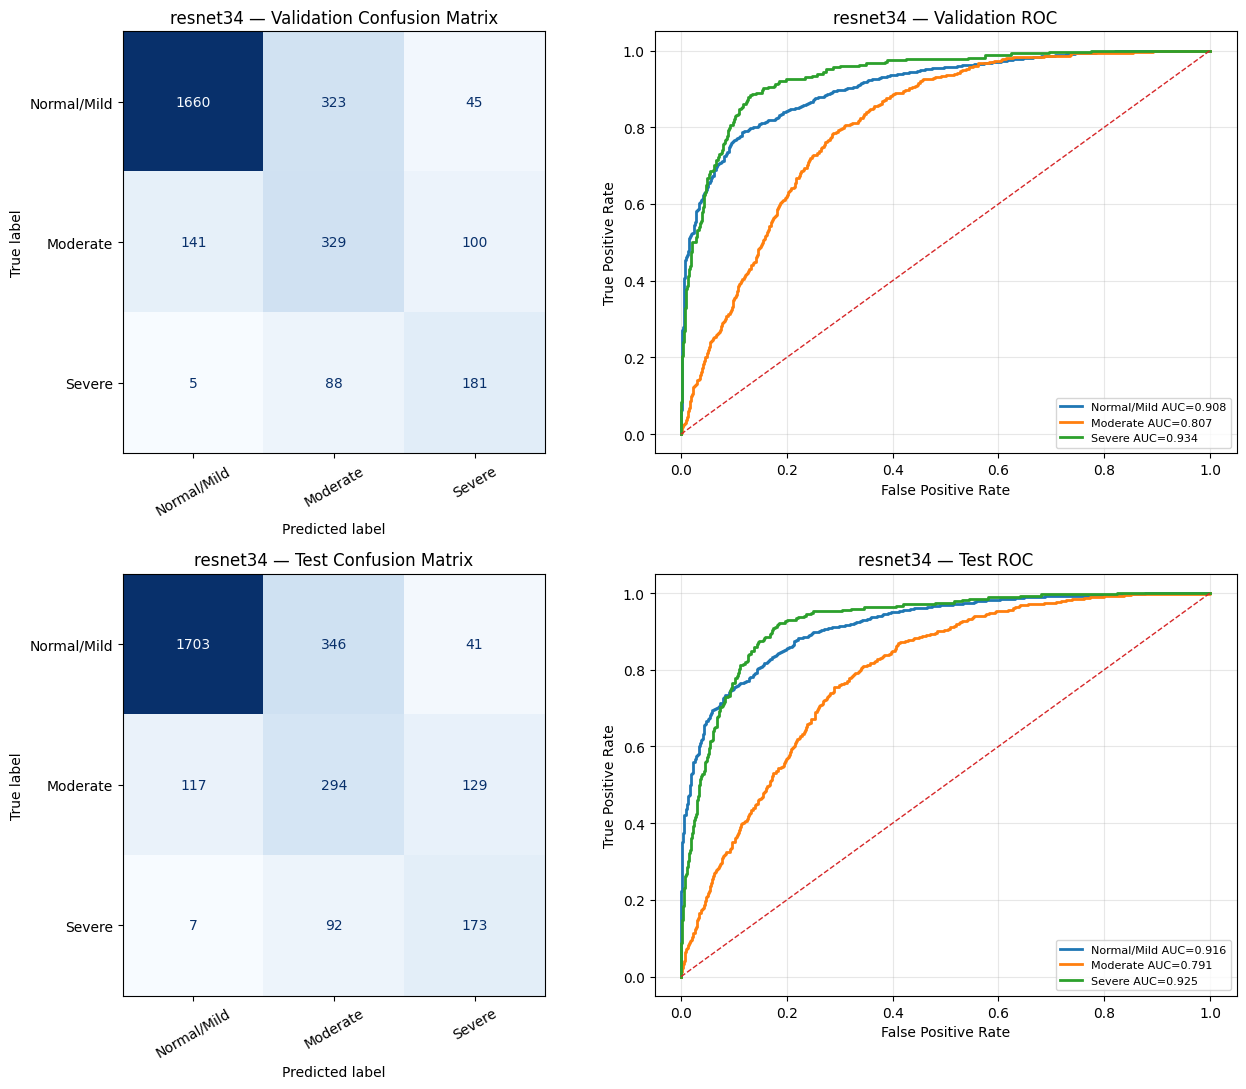


Evaluation: efficientnet_b0


split,n_samples,accuracy,log_loss,macro_auc_ovr,moderate_recall,severe_recall,positive_diagnosis_recall
validation,2872,0.7295,0.6479,0.8592,0.5158,0.6642,0.8009
test,2902,0.7205,0.6546,0.8503,0.4778,0.6066,0.7931


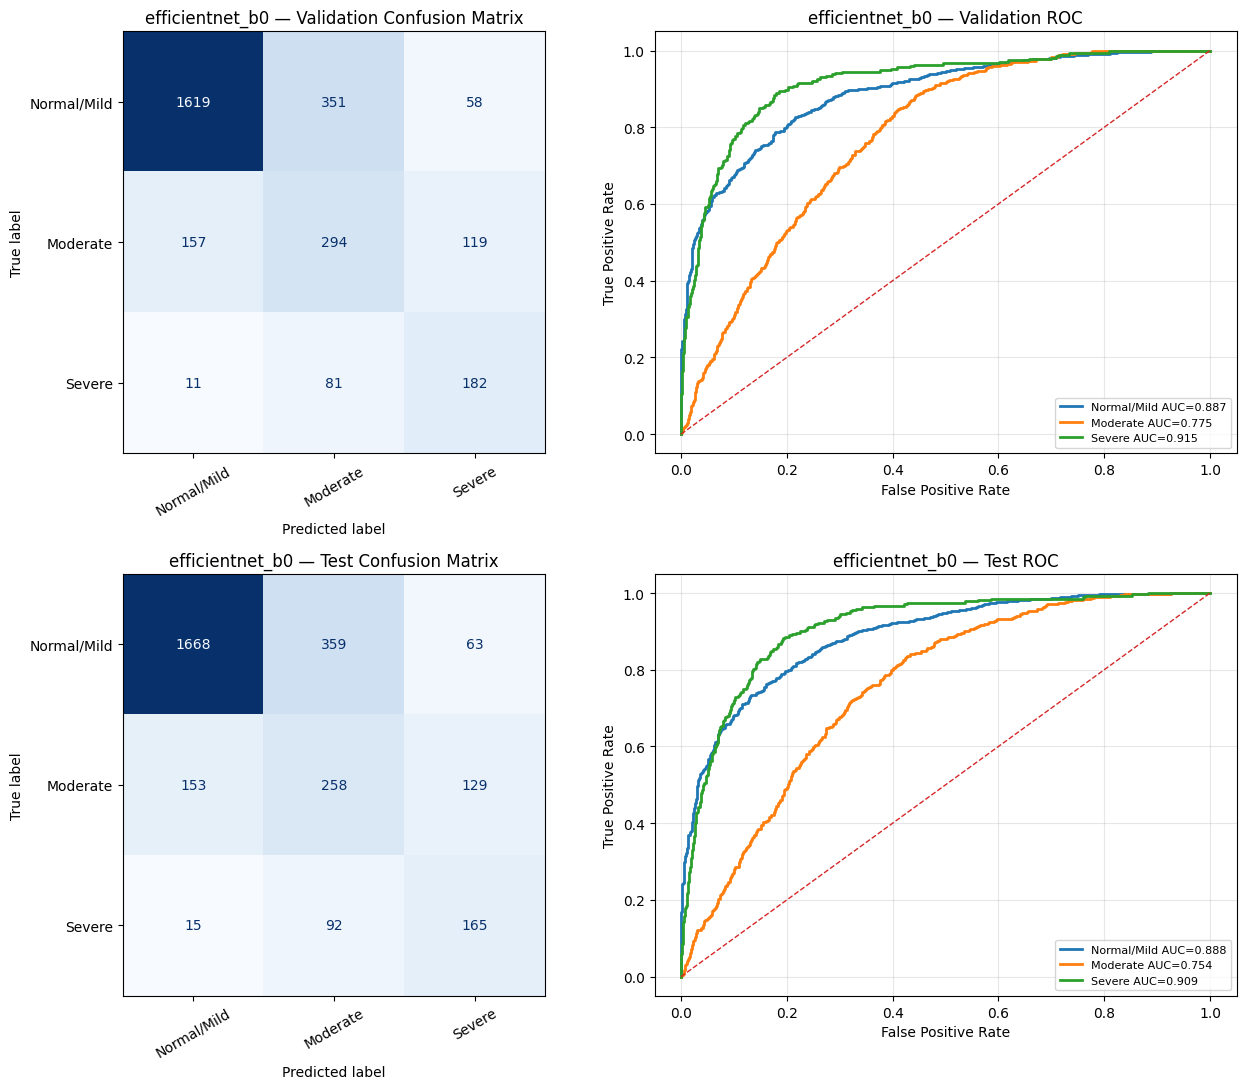


Evaluation: densenet169


split,n_samples,accuracy,log_loss,macro_auc_ovr,moderate_recall,severe_recall,positive_diagnosis_recall
validation,2872,0.6971,0.6937,0.8418,0.4070,0.7518,0.8140
test,2902,0.6937,0.7038,0.8449,0.4093,0.7610,0.8313


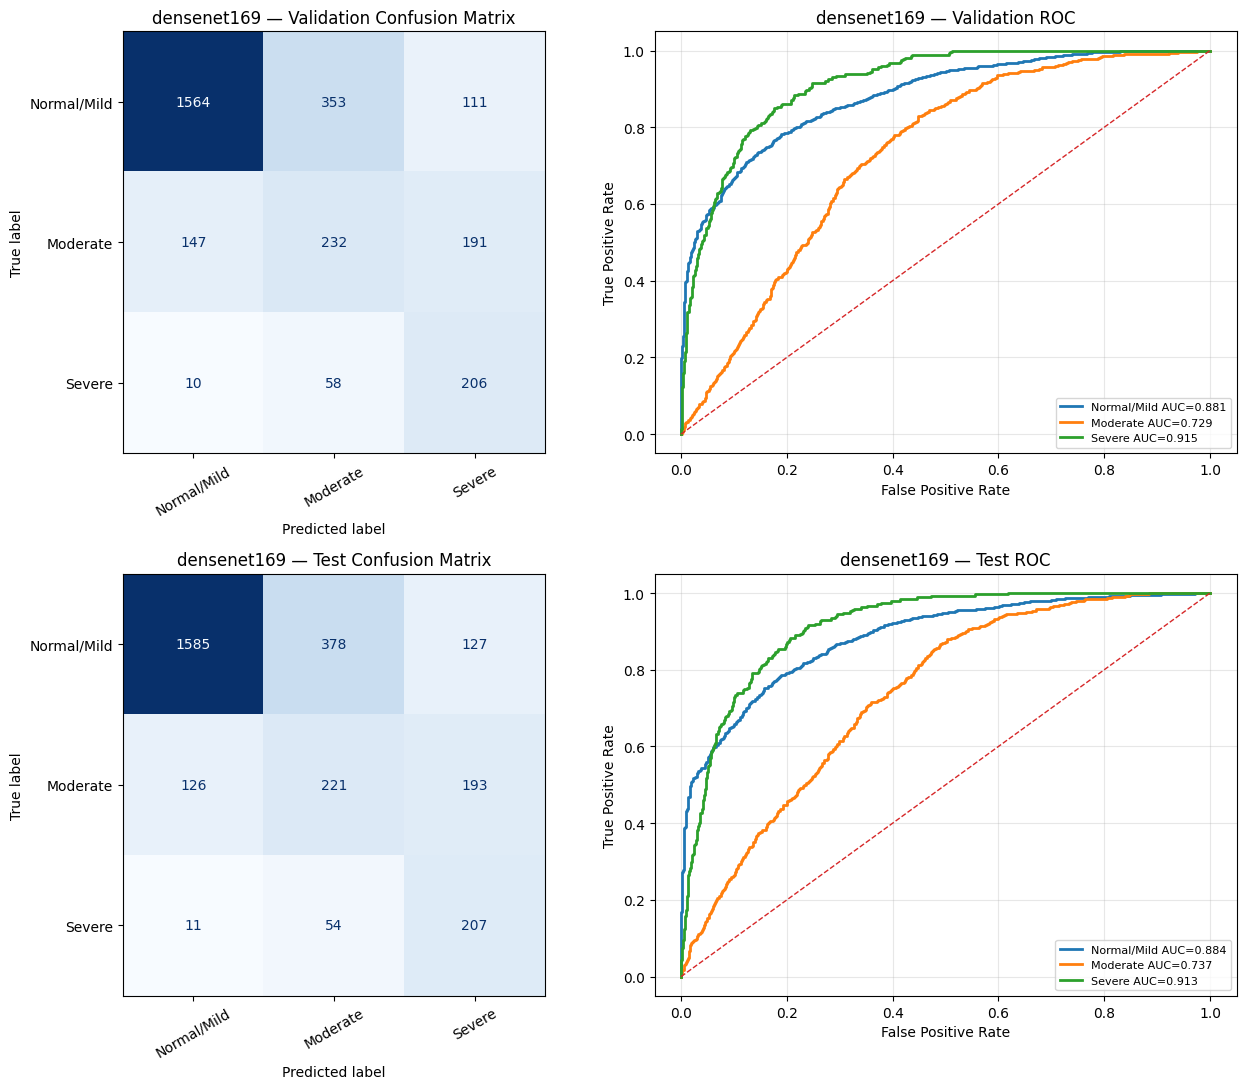


Evaluation: convnext_base


split,n_samples,accuracy,log_loss,macro_auc_ovr,moderate_recall,severe_recall,positive_diagnosis_recall
validation,2872,0.7681,0.5702,0.8969,0.5982,0.7299,0.8614
test,2902,0.7691,0.5777,0.8910,0.5778,0.7022,0.8744


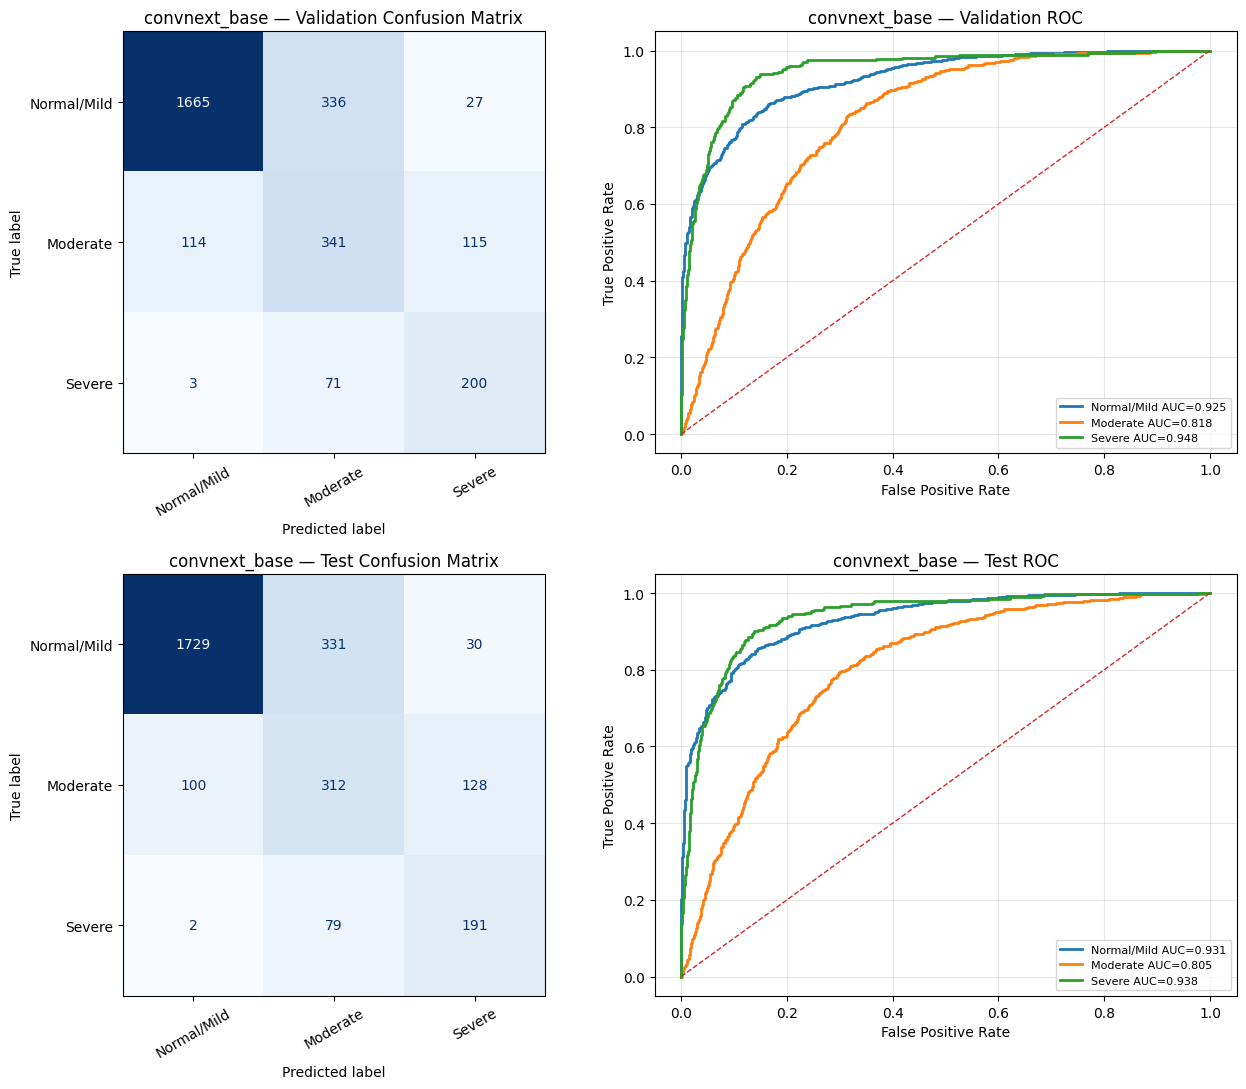


Evaluation: swin_b


split,n_samples,accuracy,log_loss,macro_auc_ovr,moderate_recall,severe_recall,positive_diagnosis_recall
validation,2872,0.7855,0.5648,0.9031,0.6281,0.7993,0.8910
test,2902,0.7819,0.5778,0.8957,0.6130,0.7500,0.9076


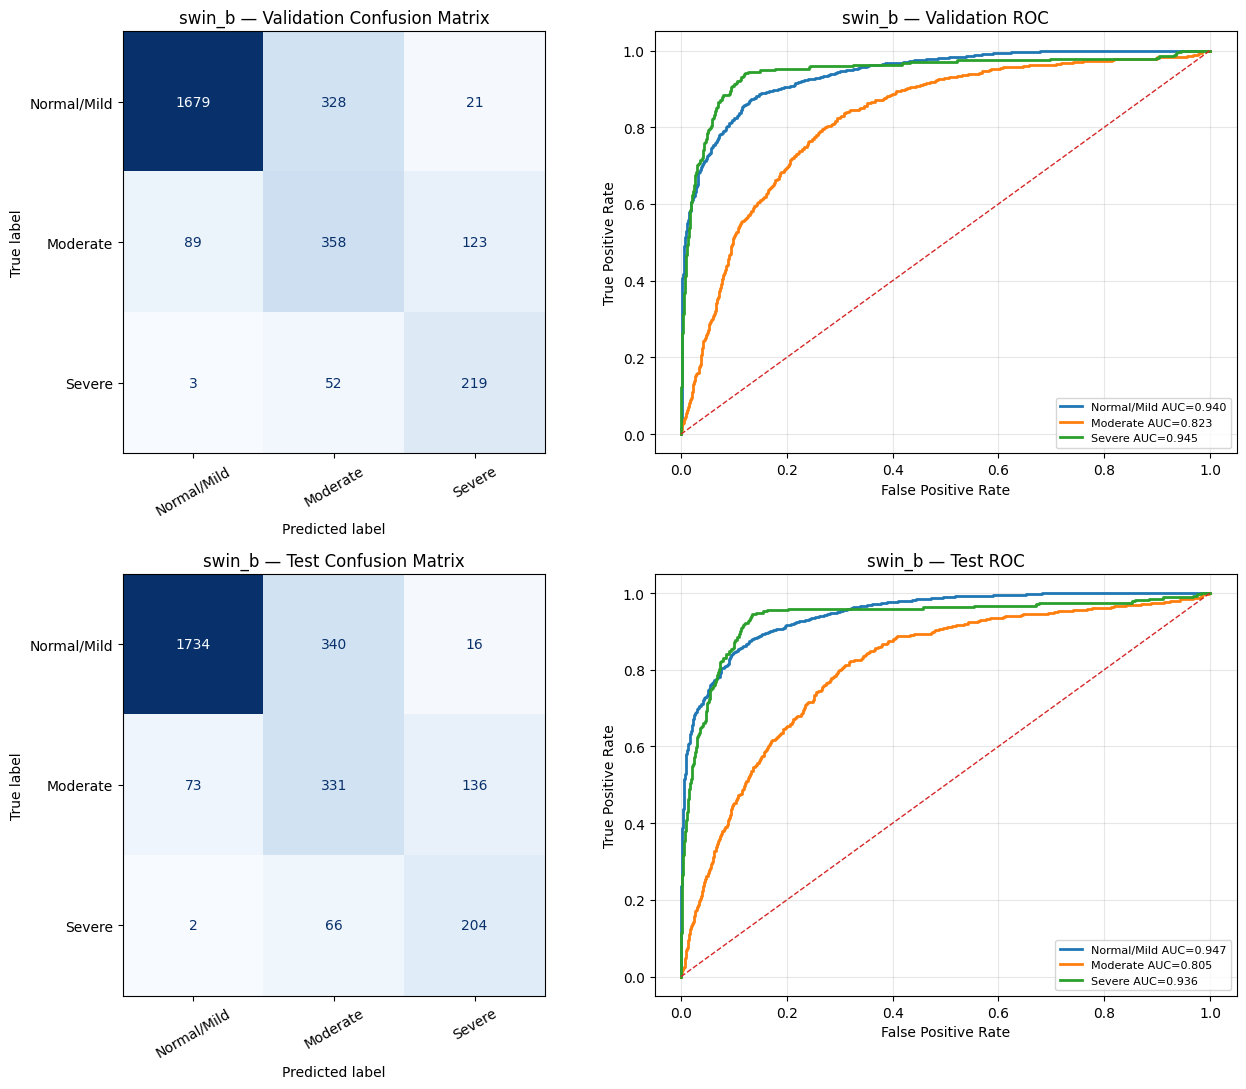

In [16]:
# ============================================================
# EVALUATE EACH MODEL ON VALIDATION AND TEST SETS
# Table is displayed separately for each model.
# F1 metrics and model column are hidden.
# ============================================================

all_evaluation_rows = []

y_val = val_pred_df["y_true"].values
y_test = test_pred_df["y_true"].values

display_metric_cols = [
    "split",
    "n_samples",
    "accuracy",
    "log_loss",
    "macro_auc_ovr",
    "moderate_recall",
    "severe_recall",
    "positive_diagnosis_recall",
]

for model_name in MODEL_NAMES:
    print("\n" + "=" * 80)
    print("Evaluation:", model_name)
    print("=" * 80)

    val_probs = val_pred_df[
        [f"{model_name}_p0", f"{model_name}_p1", f"{model_name}_p2"]
    ].values

    test_probs = test_pred_df[
        [f"{model_name}_p0", f"{model_name}_p1", f"{model_name}_p2"]
    ].values

    # Metric rows
    val_row = compute_metric_row(
        split_name="validation",
        model_name=model_name,
        y_true=y_val,
        probs=val_probs,
    )

    test_row = compute_metric_row(
        split_name="test",
        model_name=model_name,
        y_true=y_test,
        probs=test_probs,
    )

    all_evaluation_rows.extend([val_row, test_row])

    # Display table for this model only.
    single_model_eval_df = pd.DataFrame([val_row, test_row])

    display(
        single_model_eval_df[display_metric_cols]
        .style
        .format({
            "accuracy": "{:.4f}",
            "log_loss": "{:.4f}",
            "macro_auc_ovr": "{:.4f}",
            "moderate_recall": "{:.4f}",
            "severe_recall": "{:.4f}",
            "positive_diagnosis_recall": "{:.4f}",
        })
        .hide(axis="index")
    )
    
    # 2x2 grid: val CM, val ROC, test CM, test ROC
    plot_val_test_grid(
        model_name=model_name,
        y_val=y_val,
        val_probs=val_probs,
        y_test=y_test,
        test_probs=test_probs,
    )

# Optional combined table for later use, not displayed by default.
model_eval_df = pd.DataFrame(all_evaluation_rows)

## 12. Ensemble 1 — validation-estimated weighted probability average


Ensemble: Simple Probability Average


split,n_samples,accuracy,log_loss,macro_auc_ovr,moderate_recall,severe_recall,positive_diagnosis_recall
validation,2872,0.7859,0.5574,0.9077,0.6140,0.7920,0.8768
test,2902,0.7722,0.5631,0.9020,0.5778,0.7390,0.8892


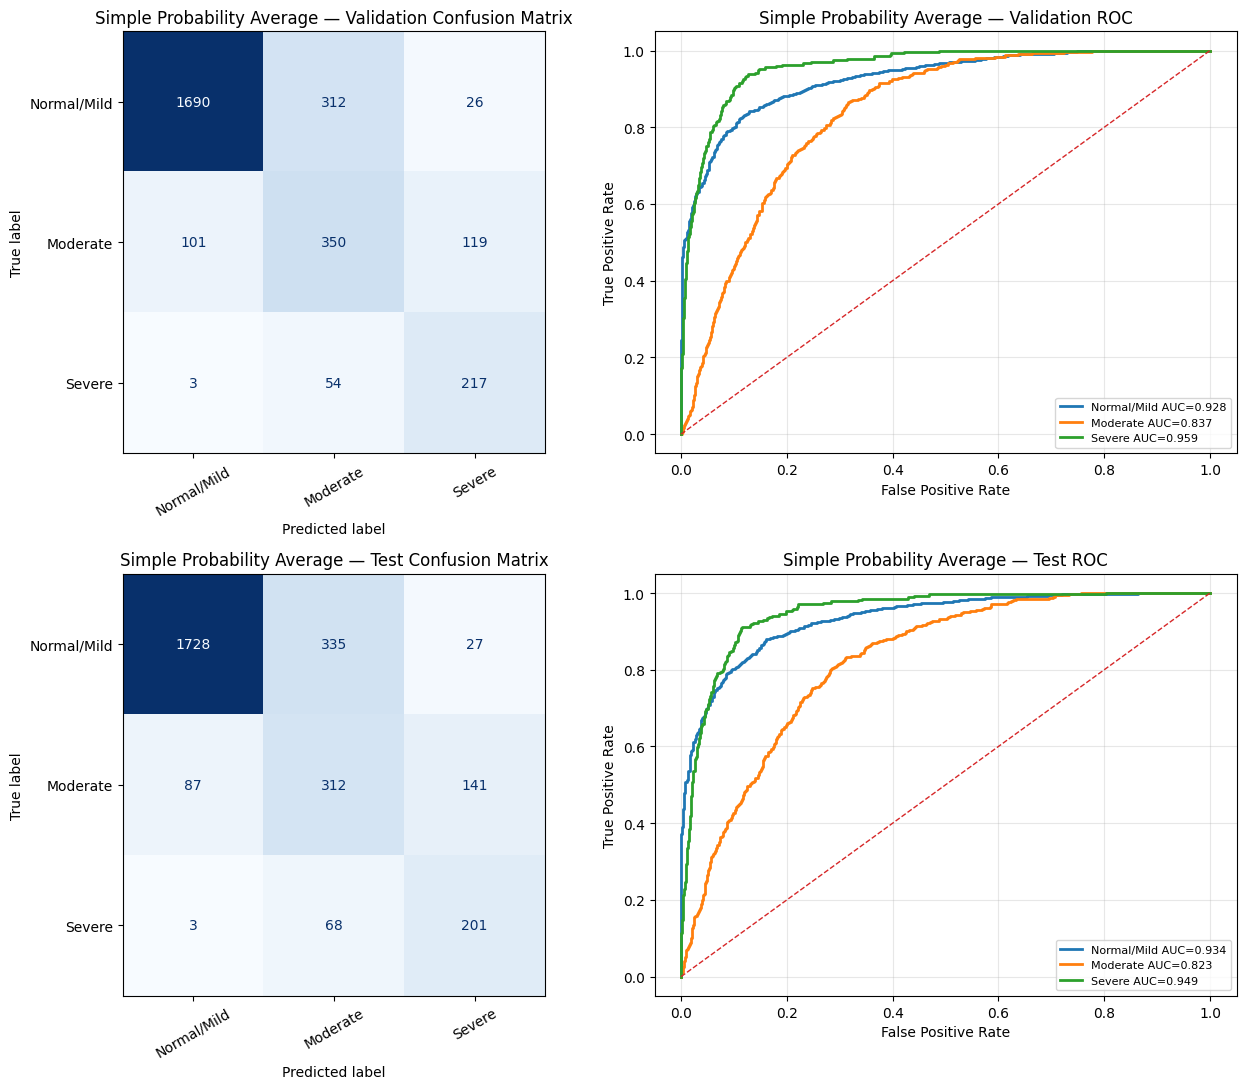

In [17]:
# ============================================================
# ENSEMBLE 1: WEIGHTED PROBABILITY AVERAGE
# ============================================================
# We estimate model weights on the VALIDATION set and evaluate once on TEST.

val_probs_by_model = [
    val_pred_df[[f"{name}_p0", f"{name}_p1", f"{name}_p2"]].values
    for name in MODEL_NAMES
]

test_probs_by_model = [
    test_pred_df[[f"{name}_p0", f"{name}_p1", f"{name}_p2"]].values
    for name in MODEL_NAMES
]

y_val = val_pred_df["y_true"].values
y_test = test_pred_df["y_true"].values

val_weights_samples = get_sample_weights(y_val)
test_weights_samples = get_sample_weights(y_test)


def weighted_average(probs_by_model, weights):
    weights = np.asarray(weights, dtype=np.float64)
    weights = weights / weights.sum()

    out = np.zeros_like(probs_by_model[0], dtype=np.float64)
    for w, probs in zip(weights, probs_by_model):
        out += w * probs

    out = out / out.sum(axis=1, keepdims=True)
    return out


def display_ensemble_report(
    ensemble_name,
    y_val,
    val_probs,
    y_test,
    test_probs,
):
    val_row = compute_metric_row(
        split_name="validation",
        model_name=ensemble_name,
        y_true=y_val,
        probs=val_probs,
    )

    test_row = compute_metric_row(
        split_name="test",
        model_name=ensemble_name,
        y_true=y_test,
        probs=test_probs,
    )

    if "ensemble_evaluation_rows" not in globals():
        globals()["ensemble_evaluation_rows"] = []

    ensemble_evaluation_rows.extend([val_row, test_row])

    display_metric_cols = [
        "split",
        "n_samples",
        "accuracy",
        "log_loss",
        "macro_auc_ovr",
        "moderate_recall",
        "severe_recall",
        "positive_diagnosis_recall",
    ]

    single_ensemble_eval_df = pd.DataFrame([val_row, test_row])

    display(
        single_ensemble_eval_df[display_metric_cols]
        .style
        .format({
            "accuracy": "{:.4f}",
            "log_loss": "{:.4f}",
            "macro_auc_ovr": "{:.4f}",
            "moderate_recall": "{:.4f}",
            "severe_recall": "{:.4f}",
            "positive_diagnosis_recall": "{:.4f}",
        })
        .hide(axis="index")
    )

    plot_val_test_grid(
        model_name=ensemble_name,
        y_val=y_val,
        val_probs=val_probs,
        y_test=y_test,
        test_probs=test_probs,
    )

# ------------------------------------------------------------
# 1. Simple probability average baseline
# ------------------------------------------------------------

equal_weights = np.ones(len(MODEL_NAMES)) / len(MODEL_NAMES)

val_simple_probs = weighted_average(
    val_probs_by_model,
    equal_weights,
)

test_simple_probs = weighted_average(
    test_probs_by_model,
    equal_weights,
)

print("\n" + "=" * 80)
print("Ensemble: Simple Probability Average")
print("=" * 80)

display_ensemble_report(
    ensemble_name="Simple Probability Average",
    y_val=y_val,
    val_probs=val_simple_probs,
    y_test=y_test,
    test_probs=test_simple_probs,
)



Regularized validation-optimized weights:
resnet34        : 0.1425
efficientnet_b0 : 0.0402
densenet169     : 0.0000
convnext_base   : 0.2214
swin_b          : 0.5959

Ensemble: Validation-Optimized Weighted Probability Average
 


split,n_samples,accuracy,log_loss,macro_auc_ovr,moderate_recall,severe_recall,positive_diagnosis_recall
validation,2872,0.7946,0.5312,0.9132,0.6386,0.8102,0.8898
test,2902,0.7812,0.5398,0.9063,0.5981,0.7390,0.8978


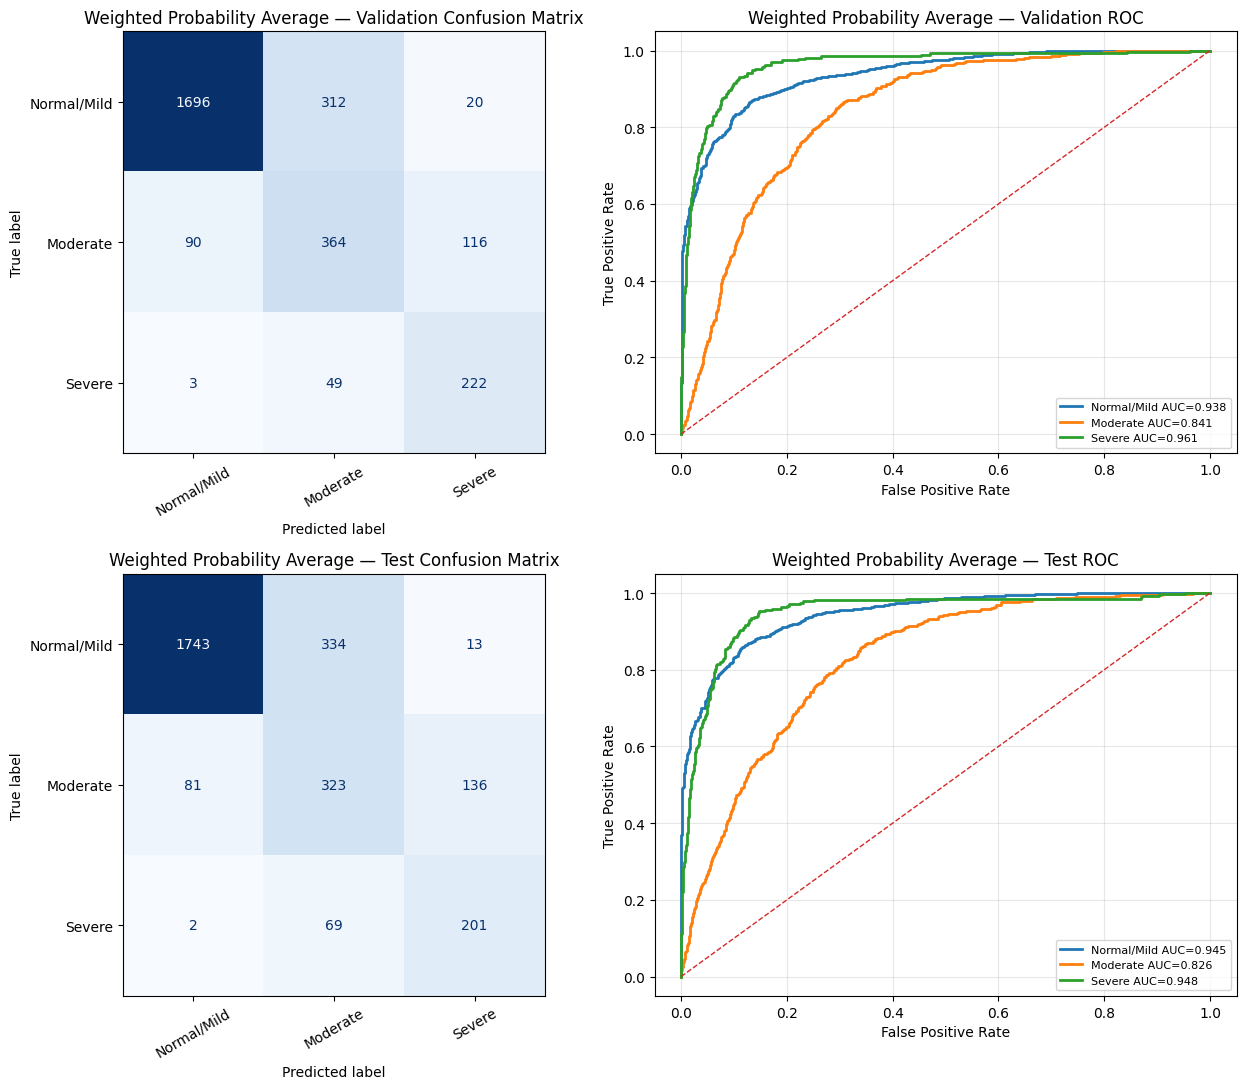

In [18]:
# ============================================================
# VALIDATION-OPTIMIZED WEIGHTS WITH MINIMUM WEIGHT CONSTRAINT
# ============================================================

MIN_WEIGHT = 0.00
n_models = len(MODEL_NAMES)

def objective(w):
    probs = weighted_average(val_probs_by_model, w)
    return log_loss(
        y_val,
        probs,
        labels=CLASS_LABELS,
        sample_weight=val_weights_samples,
    )

from scipy.optimize import minimize

equal_weights = np.ones(n_models) / n_models

constraints = (
    {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
)

bounds = [
    (MIN_WEIGHT, 1.0)
    for _ in MODEL_NAMES
]

result = minimize(
    objective,
    x0=equal_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"maxiter": 1000, "ftol": 1e-10},
)

best_weights_regularized = np.clip(result.x, MIN_WEIGHT, 1.0)
best_weights_regularized = best_weights_regularized / best_weights_regularized.sum()

print("\nRegularized validation-optimized weights:")
for name, weight in zip(MODEL_NAMES, best_weights_regularized):
    print(f"{name:16s}: {weight:.4f}")

val_weighted_probs = weighted_average(val_probs_by_model, best_weights_regularized)
test_weighted_probs = weighted_average(test_probs_by_model, best_weights_regularized)

val_weighted_probs = weighted_average(
    val_probs_by_model,
    best_weights_regularized,
)

test_weighted_probs = weighted_average(
    test_probs_by_model,
    best_weights_regularized,
)

print("\n" + "=" * 80)
print("Ensemble: Validation-Optimized Weighted Probability Average")
print("=" * 80)
print(" ")

display_ensemble_report(
    ensemble_name="Weighted Probability Average",
    y_val=y_val,
    val_probs=val_weighted_probs,
    y_test=y_test,
    test_probs=test_weighted_probs,
)

## 13. Ensemble 2 — logistic-regression stacking trained on validation, tested on test

In [19]:
# ============================================================
# ENSEMBLE 2: LOGISTIC REGRESSION STACKING
# ============================================================
# Fit only on validation predictions, evaluate only on test predictions.

ensemble_name = "Logistic Regression Stacking"

X_val_stack, prob_cols = collect_feature_matrix(val_pred_df, MODEL_NAMES)
X_test_stack, _ = collect_feature_matrix(test_pred_df, MODEL_NAMES)

y_val = val_pred_df["y_true"].values
y_test = test_pred_df["y_true"].values

val_sample_weights = get_sample_weights(y_val)
test_sample_weights = get_sample_weights(y_test)

stack_lr = LogisticRegression(
    penalty="l2",
    C=0.5,
    solver="lbfgs",
    multi_class="multinomial",
    max_iter=3000,
    random_state=42,
)

stack_lr.fit(
    X_val_stack,
    y_val,
    sample_weight=val_sample_weights,
)

val_lr_probs = align_predict_proba(stack_lr, X_val_stack)
test_lr_probs = align_predict_proba(stack_lr, X_test_stack)

# ============================================================
# INSPECT LOGISTIC REGRESSION STACKING MODEL
# ============================================================

print("=" * 80)
print("LOGISTIC REGRESSION STACKING MODEL")
print("=" * 80)

print("\nClasses learned by the model:")
for class_id in stack_lr.classes_:
    print(f"  {class_id}: {TARGET_NAMES[class_id]}")

print("\nModel configuration:")
print(stack_lr)

print("\nIntercepts:")
for class_id, intercept in zip(stack_lr.classes_, stack_lr.intercept_):
    print(f"  {TARGET_NAMES[class_id]:12s}: {intercept:.6f}")

# Coefficients table
coef_df = pd.DataFrame(
    stack_lr.coef_,
    index=[TARGET_NAMES[class_id] for class_id in stack_lr.classes_],
    columns=prob_cols,
)

print("\nCoefficient matrix shape:", coef_df.shape)
display(
    coef_df
    .style
    .format("{:.4f}")
    .background_gradient(axis=None)
)

# Long-form coefficient table
coef_long_df = (
    coef_df
    .reset_index(names="target_class")
    .melt(
        id_vars="target_class",
        var_name="feature",
        value_name="coefficient",
    )
)

coef_long_df["abs_coefficient"] = coef_long_df["coefficient"].abs()

print("\nTop positive coefficients per predicted class:")
for class_name in coef_df.index:
    print("\n" + "-" * 80)
    print(class_name)
    display(
        coef_long_df[coef_long_df["target_class"] == class_name]
        .sort_values("coefficient", ascending=False)
        .head(10)
        [["feature", "coefficient"]]
        .style
        .format({"coefficient": "{:.4f}"})
        .hide(axis="index")
    )

print("\nTop absolute coefficients overall:")
display(
    coef_long_df
    .sort_values("abs_coefficient", ascending=False)
    .head(20)
    [["target_class", "feature", "coefficient", "abs_coefficient"]]
    .style
    .format({
        "coefficient": "{:.4f}",
        "abs_coefficient": "{:.4f}",
    })
    .hide(axis="index")
)


LOGISTIC REGRESSION STACKING MODEL

Classes learned by the model:
  0: Normal/Mild
  1: Moderate
  2: Severe

Model configuration:
LogisticRegression(C=0.5, max_iter=3000, multi_class='multinomial',
                   random_state=42)

Intercepts:
  Normal/Mild : 0.120344
  Moderate    : 0.329620
  Severe      : -0.449964

Coefficient matrix shape: (3, 15)


,resnet34_p0,resnet34_p1,resnet34_p2,efficientnet_b0_p0,efficientnet_b0_p1,efficientnet_b0_p2,densenet169_p0,densenet169_p1,densenet169_p2,convnext_base_p0,convnext_base_p1,convnext_base_p2,swin_b_p0,swin_b_p1,swin_b_p2
Normal/Mild,0.3892,-0.1446,-0.2056,0.1988,-0.2458,0.0860,0.3726,-0.5697,0.2361,0.7351,0.1087,-0.8048,2.3107,-0.3872,-1.8845
Moderate,0.0174,0.3143,-0.2204,0.1250,0.3159,-0.3296,0.0463,-0.0105,0.0755,0.4344,-0.2437,-0.0794,-0.7153,0.6243,0.2023
Severe,-0.4066,-0.1697,0.4260,-0.3238,-0.0701,0.2436,-0.4189,0.5802,-0.3116,-1.1695,0.1350,0.8842,-1.5955,-0.2371,1.6823



Top positive coefficients per predicted class:

--------------------------------------------------------------------------------
Normal/Mild


feature,coefficient
swin_b_p0,2.3107
convnext_base_p0,0.7351
resnet34_p0,0.3892
densenet169_p0,0.3726
densenet169_p2,0.2361
efficientnet_b0_p0,0.1988
convnext_base_p1,0.1087
efficientnet_b0_p2,0.0860
resnet34_p1,-0.1446
resnet34_p2,-0.2056



--------------------------------------------------------------------------------
Moderate


feature,coefficient
swin_b_p1,0.6243
convnext_base_p0,0.4344
efficientnet_b0_p1,0.3159
resnet34_p1,0.3143
swin_b_p2,0.2023
efficientnet_b0_p0,0.1250
densenet169_p2,0.0755
densenet169_p0,0.0463
resnet34_p0,0.0174
densenet169_p1,-0.0105



--------------------------------------------------------------------------------
Severe


feature,coefficient
swin_b_p2,1.6823
convnext_base_p2,0.8842
densenet169_p1,0.5802
resnet34_p2,0.4260
efficientnet_b0_p2,0.2436
convnext_base_p1,0.1350
efficientnet_b0_p1,-0.0701
resnet34_p1,-0.1697
swin_b_p1,-0.2371
densenet169_p2,-0.3116



Top absolute coefficients overall:


target_class,feature,coefficient,abs_coefficient
Normal/Mild,swin_b_p0,2.3107,2.3107
Normal/Mild,swin_b_p2,-1.8845,1.8845
Severe,swin_b_p2,1.6823,1.6823
Severe,swin_b_p0,-1.5955,1.5955
Severe,convnext_base_p0,-1.1695,1.1695
Severe,convnext_base_p2,0.8842,0.8842
Normal/Mild,convnext_base_p2,-0.8048,0.8048
Normal/Mild,convnext_base_p0,0.7351,0.7351
Moderate,swin_b_p0,-0.7153,0.7153
Moderate,swin_b_p1,0.6243,0.6243



Ensemble: Logistic Regression Stacking


split,n_samples,accuracy,log_loss,macro_auc_ovr,moderate_recall,severe_recall,positive_diagnosis_recall
validation,2872,0.8130,0.4410,0.9229,0.5947,0.7956,0.8602
test,2902,0.8019,0.4461,0.9174,0.5667,0.7426,0.8707


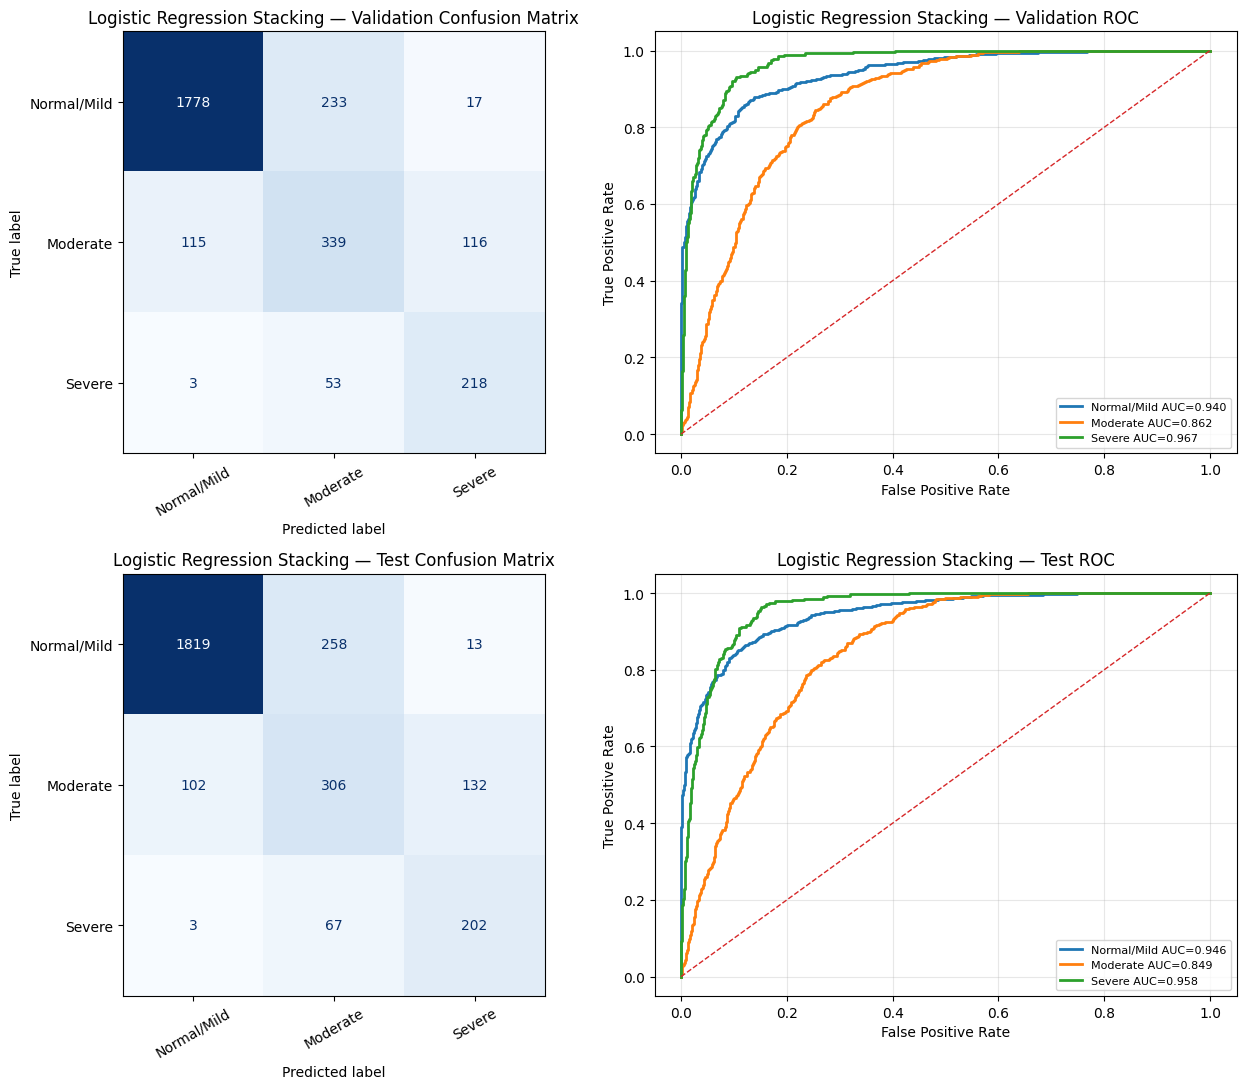

In [20]:
print("\n" + "=" * 80)
print("Ensemble:", ensemble_name)
print("=" * 80)
# ------------------------------------------------------------
# Metric table: validation + test
# ------------------------------------------------------------

val_row = compute_metric_row(
    split_name="validation",
    model_name=ensemble_name,
    y_true=y_val,
    probs=val_lr_probs,
)

test_row = compute_metric_row(
    split_name="test",
    model_name=ensemble_name,
    y_true=y_test,
    probs=test_lr_probs,
)

if "ensemble_evaluation_rows" not in globals():
    ensemble_evaluation_rows = []

ensemble_evaluation_rows.extend([val_row, test_row])

display_metric_cols = [
    "split",
    "n_samples",
    "accuracy",
    "log_loss",
    "macro_auc_ovr",
    "moderate_recall",
    "severe_recall",
    "positive_diagnosis_recall",
]

single_ensemble_eval_df = pd.DataFrame([val_row, test_row])

display(
    single_ensemble_eval_df[display_metric_cols]
    .style
    .format({
        "accuracy": "{:.4f}",
        "log_loss": "{:.4f}",
        "macro_auc_ovr": "{:.4f}",
        "moderate_recall": "{:.4f}",
        "severe_recall": "{:.4f}",
        "positive_diagnosis_recall": "{:.4f}",
    })
    .hide(axis="index")
)

# ------------------------------------------------------------
# 2x2 grid: validation CM, validation ROC, test CM, test ROC
# ------------------------------------------------------------

plot_val_test_grid(
    model_name=ensemble_name,
    y_val=y_val,
    val_probs=val_lr_probs,
    y_test=y_test,
    test_probs=test_lr_probs,
)

## 14. Ensemble 3 — shallow decision-tree stacking trained on validation, tested on test

Decision tree min_samples_leaf: 143
Decision tree depth: 3
Decision tree leaves: 7


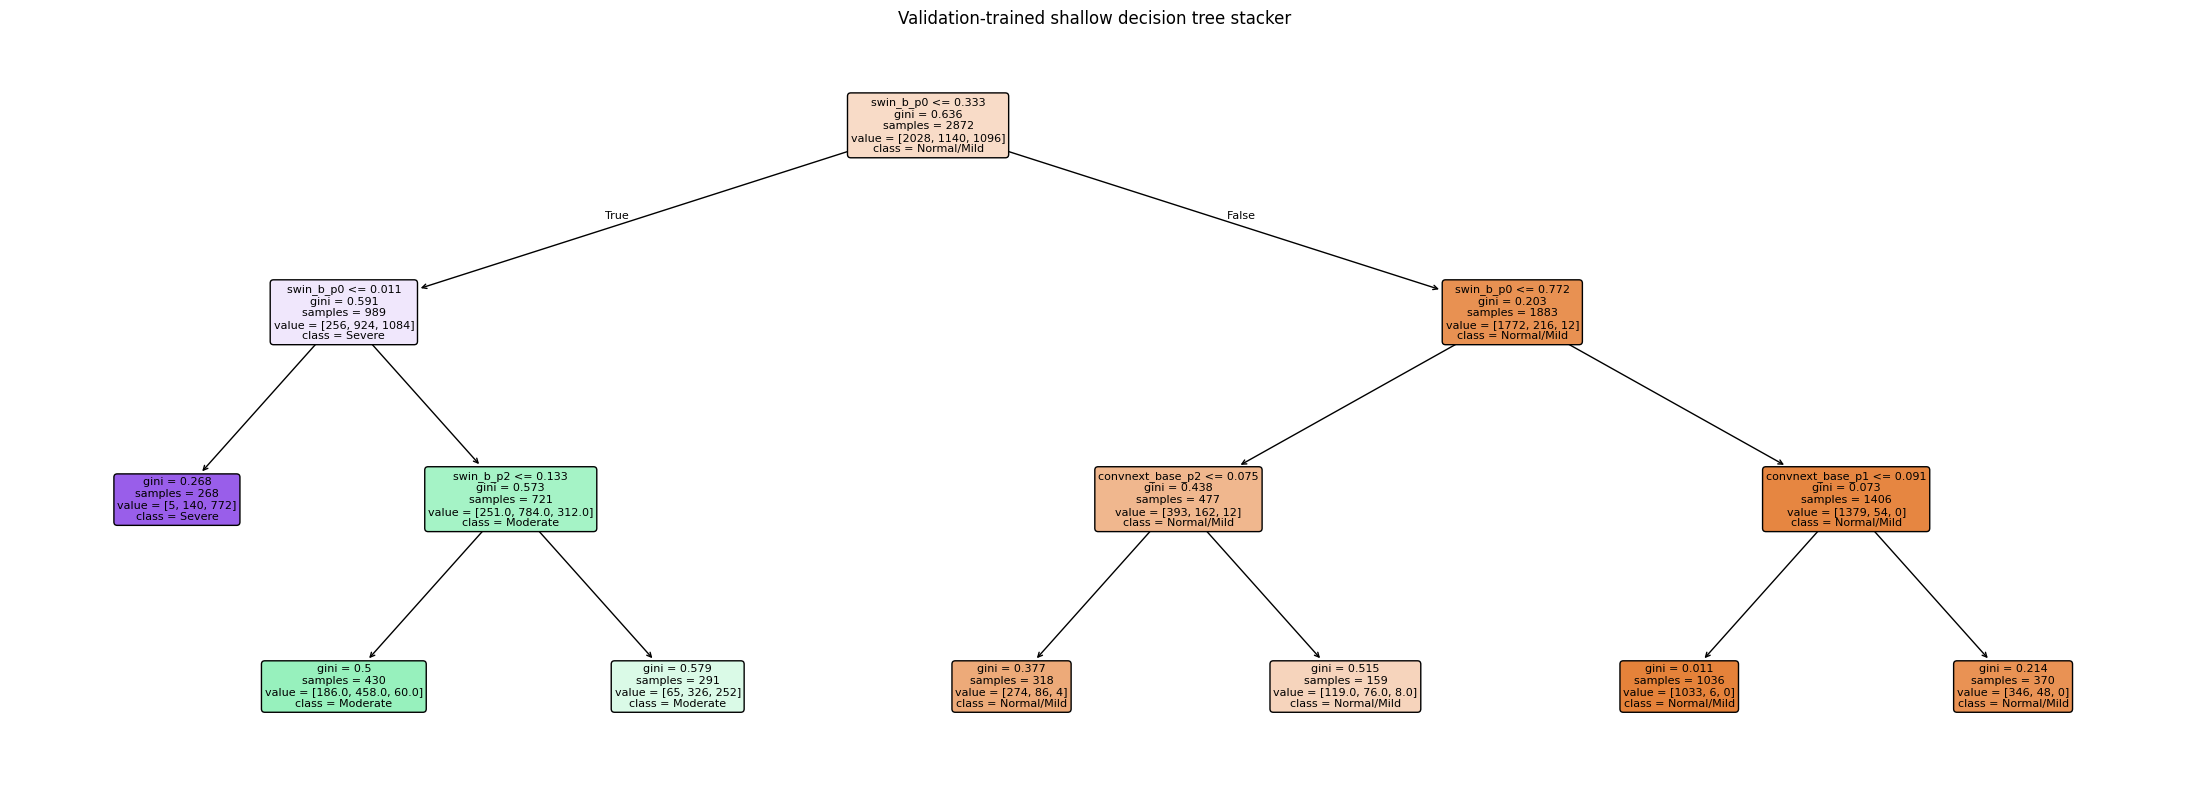

In [21]:
# ============================================================
# ENSEMBLE 3: SHALLOW DECISION TREE STACKING
# ============================================================
# Fit only on validation predictions, evaluate only on test predictions.
# A shallow tree is used to reduce overfitting.
ensemble_name = "Shallow Decision Tree Stacking"

X_val_stack, prob_cols = collect_feature_matrix(val_pred_df, MODEL_NAMES)
X_test_stack, _ = collect_feature_matrix(test_pred_df, MODEL_NAMES)

y_val = val_pred_df["y_true"].values
y_test = test_pred_df["y_true"].values

min_leaf = max(5, int(0.05 * len(y_val)))

stack_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=min_leaf,
    class_weight=CLASS_WEIGHT_MAP,
    random_state=42,
)

stack_tree.fit(X_val_stack, y_val)

val_tree_probs = align_predict_proba(stack_tree, X_val_stack)
test_tree_probs = align_predict_proba(stack_tree, X_test_stack)

print("Decision tree min_samples_leaf:", min_leaf)
print("Decision tree depth:", stack_tree.get_depth())
print("Decision tree leaves:", stack_tree.get_n_leaves())

# Optional tree visualization.
plt.figure(figsize=(22, 8))
plot_tree(
    stack_tree,
    feature_names=prob_cols,
    class_names=TARGET_NAMES,
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=8,
)
plt.title("Validation-trained shallow decision tree stacker")
plt.tight_layout()
plt.show()


split,n_samples,accuracy,log_loss,macro_auc_ovr,moderate_recall,severe_recall,positive_diagnosis_recall
validation,2872,0.8207,0.4391,0.9154,0.6877,0.7044,0.8685
test,2902,0.8060,0.4517,0.9071,0.6593,0.6287,0.8744


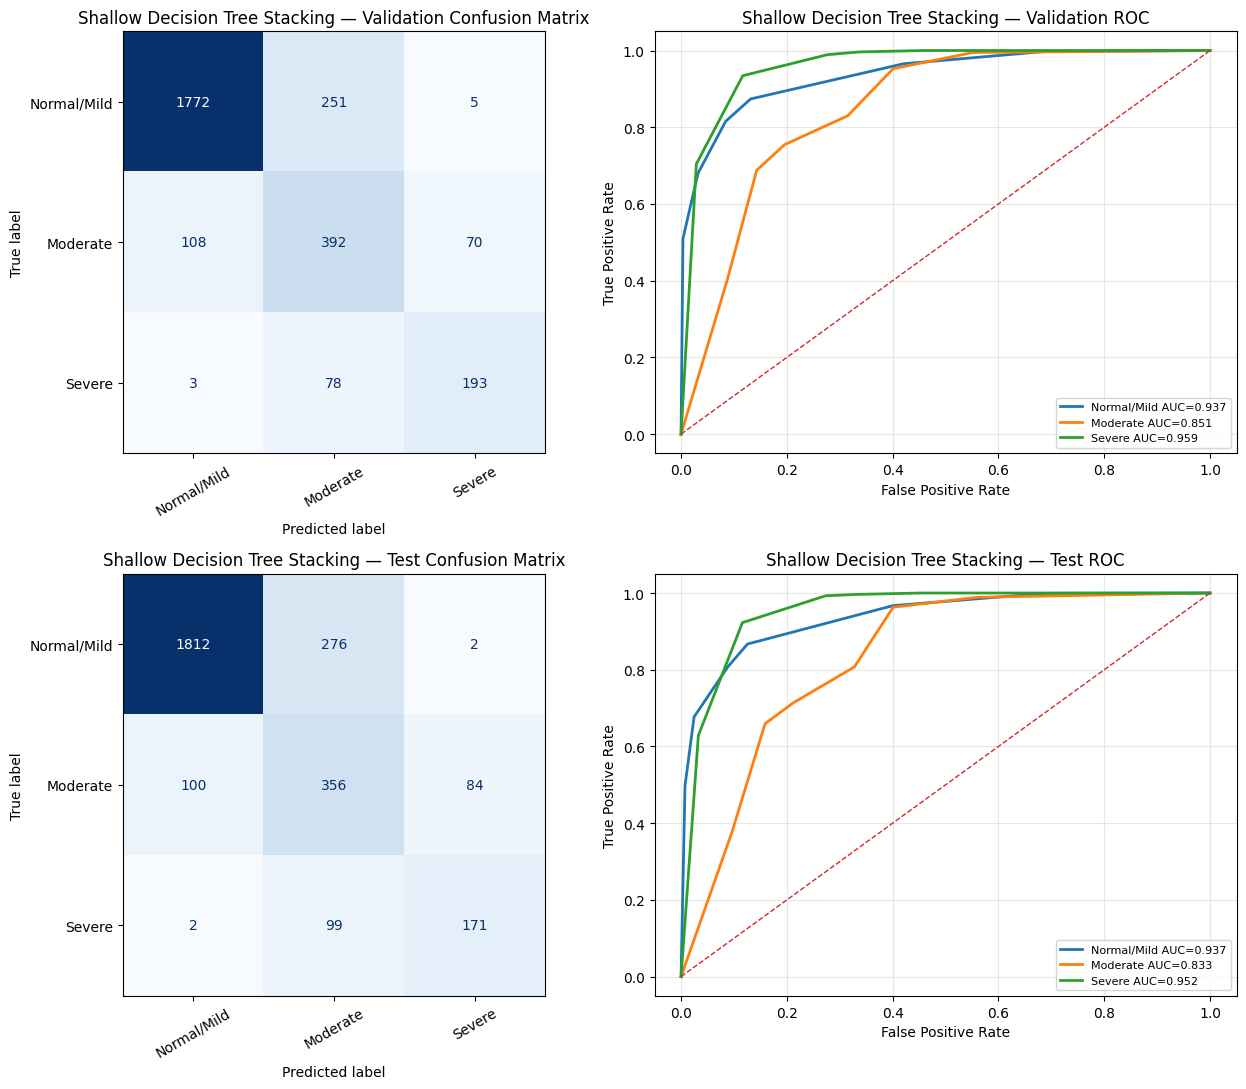

In [22]:
# ============================================================
# EVALUATION — SHALLOW DECISION TREE STACKING
# ============================================================

val_row = compute_metric_row(
    split_name="validation",
    model_name=ensemble_name,
    y_true=y_val,
    probs=val_tree_probs,
)

test_row = compute_metric_row(
    split_name="test",
    model_name=ensemble_name,
    y_true=y_test,
    probs=test_tree_probs,
)

if "ensemble_evaluation_rows" not in globals():
    ensemble_evaluation_rows = []

ensemble_evaluation_rows.extend([val_row, test_row])

display_metric_cols = [
    "split",
    "n_samples",
    "accuracy",
    "log_loss",
    "macro_auc_ovr",
    "moderate_recall",
    "severe_recall",
    "positive_diagnosis_recall",
]

single_ensemble_eval_df = pd.DataFrame([val_row, test_row])

display(
    single_ensemble_eval_df[display_metric_cols]
    .style
    .format({
        "accuracy": "{:.4f}",
        "log_loss": "{:.4f}",
        "macro_auc_ovr": "{:.4f}",
        "moderate_recall": "{:.4f}",
        "severe_recall": "{:.4f}",
        "positive_diagnosis_recall": "{:.4f}",
    })
    .hide(axis="index")
)

plot_val_test_grid(
    model_name=ensemble_name,
    y_val=y_val,
    val_probs=val_tree_probs,
    y_test=y_test,
    test_probs=test_tree_probs,
)

## Safety-net ensemble (MAX) 


Ensemble: Safety-Net Max-Severity Ensemble


split,n_samples,accuracy,log_loss,macro_auc_ovr,moderate_recall,severe_recall,positive_diagnosis_recall
validation,2872,0.6473,4.8730,0.7690,0.4754,0.9307,0.9526
test,2902,0.6361,5.0273,0.7603,0.4426,0.9265,0.9581


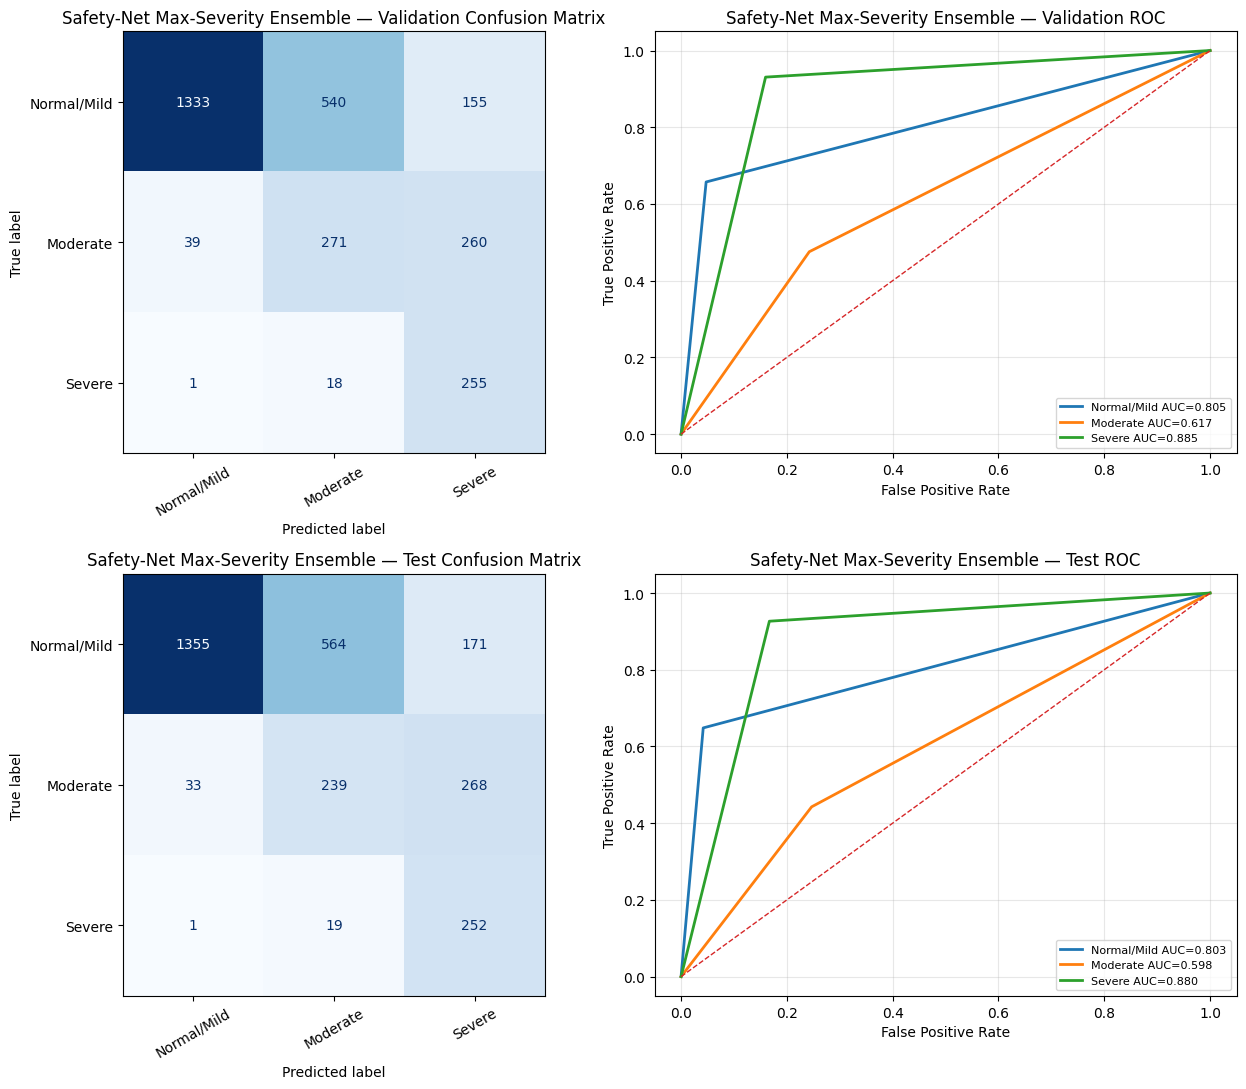

In [23]:
# ============================================================
# ENSEMBLE 5: SAFETY-NET MAX-SEVERITY ENSEMBLE
# ============================================================
# Rule:
#   If any model predicts Severe -> final prediction = Severe
#   Else if any model predicts Moderate -> final prediction = Moderate
#   Else -> final prediction = Normal/Mild
#
# This prioritizes sensitivity to positive / severe findings.
# The probability vector is created as a hard one-hot encoding,
# so log loss may be poor compared with probability-based ensembles.

ensemble_name = "Safety-Net Max-Severity Ensemble"


def safety_net_max_severity(probs_by_model):
    """
    probs_by_model: list of arrays, each shape [n_samples, 3]
    Returns:
        hard_probs: one-hot probabilities, shape [n_samples, 3]
        final_pred: labels, shape [n_samples]
    """
    model_preds = np.stack(
        [probs.argmax(axis=1) for probs in probs_by_model],
        axis=1,
    )

    # Max class = worst severity because:
    # 0 = Normal/Mild, 1 = Moderate, 2 = Severe
    final_pred = model_preds.max(axis=1)

    hard_probs = np.zeros((len(final_pred), 3), dtype=np.float64)
    hard_probs[np.arange(len(final_pred)), final_pred] = 1.0

    # Avoid infinite log loss from exact zeros.
    eps = 1e-6
    hard_probs = np.clip(hard_probs, eps, 1.0 - eps)
    hard_probs = hard_probs / hard_probs.sum(axis=1, keepdims=True)

    return hard_probs, final_pred


val_safety_probs, val_safety_pred = safety_net_max_severity(val_probs_by_model)
test_safety_probs, test_safety_pred = safety_net_max_severity(test_probs_by_model)

print("\n" + "=" * 80)
print("Ensemble:", ensemble_name)
print("=" * 80)

# Metric table
val_row = compute_metric_row(
    split_name="validation",
    model_name=ensemble_name,
    y_true=y_val,
    probs=val_safety_probs,
)

test_row = compute_metric_row(
    split_name="test",
    model_name=ensemble_name,
    y_true=y_test,
    probs=test_safety_probs,
)

if "ensemble_evaluation_rows" not in globals():
    ensemble_evaluation_rows = []

ensemble_evaluation_rows.extend([val_row, test_row])

display_metric_cols = [
    "split",
    "n_samples",
    "accuracy",
    "log_loss",
    "macro_auc_ovr",
    "moderate_recall",
    "severe_recall",
    "positive_diagnosis_recall",
]

single_ensemble_eval_df = pd.DataFrame([val_row, test_row])

display(
    single_ensemble_eval_df[display_metric_cols]
    .style
    .format({
        "accuracy": "{:.4f}",
        "log_loss": "{:.4f}",
        "macro_auc_ovr": "{:.4f}",
        "moderate_recall": "{:.4f}",
        "severe_recall": "{:.4f}",
        "positive_diagnosis_recall": "{:.4f}",
    })
    .hide(axis="index")
)

plot_val_test_grid(
    model_name=ensemble_name,
    y_val=y_val,
    val_probs=val_safety_probs,
    y_test=y_test,
    test_probs=test_safety_probs,
)

## 15. Compact comparison on the test set

In [24]:
# ============================================================
# COMPACT TEST COMPARISON
# ============================================================
def safe_log_loss(y_true, probs, sample_weight=None):
    return log_loss(
        y_true,
        probs,
        labels=CLASS_LABELS,
        sample_weight=sample_weight,
    )
    
comparison_rows = []

def add_comparison(name, probs):
    y = test_pred_df["y_true"].values
    pred = probs.argmax(axis=1)
    weights = get_sample_weights(y)

    # Positive diagnosis:
    # true positive condition = Moderate or Severe
    # predicted positive condition = Moderate or Severe
    y_positive = y > 0
    pred_positive = pred > 0

    positive_cases_total = int(y_positive.sum())
    predicted_positive_total = int(pred_positive.sum())

    true_positive_diagnosis = int((y_positive & pred_positive).sum())
    false_negative_diagnosis = int((y_positive & ~pred_positive).sum())

    # False alarm = predicted Moderate/Severe while true class is Normal/Mild
    false_alarms = int((~y_positive & pred_positive).sum())

    class_recalls = recall_score(
        y,
        pred,
        labels=CLASS_LABELS,
        average=None,
        zero_division=0,
    )

    row = {
        "model": name,
        "n_test": len(y),

        "test_accuracy": accuracy_score(y, pred),
        "test_log_loss": safe_log_loss(y, probs),
        "test_weighted_log_loss": safe_log_loss(
            y,
            probs,
            sample_weight=weights,
        ),
        "test_macro_auc_ovr": safe_multiclass_auc(y, probs),

        "moderate_recall": class_recalls[1],
        "severe_recall": class_recalls[2],
        "positive_diagnosis_recall": positive_diagnosis_recall(y, pred),

        "positive_cases_total": positive_cases_total,
        "positive_detected": true_positive_diagnosis,
        "positive_missed": false_negative_diagnosis,
        "predicted_positive_total": predicted_positive_total,
        "false_alarms": false_alarms,
    }

    comparison_rows.append(row)


# ------------------------------------------------------------
# Individual models
# ------------------------------------------------------------

for model_name in MODEL_NAMES:
    probs = test_pred_df[
        [f"{model_name}_p0", f"{model_name}_p1", f"{model_name}_p2"]
    ].values

    add_comparison(model_name, probs)


# ------------------------------------------------------------
# Ensembles
# Only add variables that exist in the notebook session.
# ------------------------------------------------------------

optional_ensembles = {
    "simple_probability_average": "test_simple_probs",
    "weighted_probability_average_val_estimated": "test_weighted_probs",
    "logistic_regression_stacking_val_trained": "test_lr_probs",
    "decision_tree_stacking_val_trained": "test_tree_probs",
    "safety_net_max_severity": "test_safety_probs",
    "threshold_safety_net": "test_threshold_probs",
}

for ensemble_name, variable_name in optional_ensembles.items():
    if variable_name in globals():
        add_comparison(
            ensemble_name,
            globals()[variable_name],
        )


comparison_df = pd.DataFrame(comparison_rows)

display_cols = [
    "model",
    "n_test",
    "test_accuracy",
    "test_weighted_log_loss",
    "test_log_loss",
    "test_macro_auc_ovr",
    "moderate_recall",
    "severe_recall",
    "positive_diagnosis_recall",
    "positive_cases_total",
    "positive_detected",
    "positive_missed",
    "predicted_positive_total",
    "false_alarms",
]

comparison_df = comparison_df[display_cols].sort_values(
    by=[
        "positive_diagnosis_recall",
        "severe_recall",
        "test_weighted_log_loss",
    ],
    ascending=[
        False,
        False,
        True,
    ],
)

display(
    comparison_df
    .style
    .format({
        "test_accuracy": "{:.4f}",
        "test_weighted_log_loss": "{:.4f}",
        "test_log_loss": "{:.4f}",
        "test_macro_auc_ovr": "{:.4f}",
        "moderate_recall": "{:.4f}",
        "severe_recall": "{:.4f}",
        "positive_diagnosis_recall": "{:.4f}",
    })
    .hide(axis="index")
)

model,n_test,test_accuracy,test_weighted_log_loss,test_log_loss,test_macro_auc_ovr,moderate_recall,severe_recall,positive_diagnosis_recall,positive_cases_total,positive_detected,positive_missed,predicted_positive_total,false_alarms
safety_net_max_severity,2902,0.6361,4.5976,5.0273,0.7603,0.4426,0.9265,0.9581,812,778,34,1513,735
swin_b,2902,0.7819,0.6189,0.5778,0.8957,0.6130,0.7500,0.9076,812,737,75,1093,356
weighted_probability_average_val_estimated,2902,0.7812,0.5784,0.5398,0.9063,0.5981,0.7390,0.8978,812,729,83,1076,347
simple_probability_average,2902,0.7722,0.6033,0.5631,0.9020,0.5778,0.7390,0.8892,812,722,90,1084,362
convnext_base,2902,0.7691,0.6301,0.5777,0.8910,0.5778,0.7022,0.8744,812,710,102,1071,361
decision_tree_stacking_val_trained,2902,0.8060,0.5399,0.4517,0.9071,0.6593,0.6287,0.8744,812,710,102,988,278
logistic_regression_stacking_val_trained,2902,0.8019,0.5358,0.4461,0.9174,0.5667,0.7426,0.8707,812,707,105,978,271
resnet34,2902,0.7478,0.6642,0.6048,0.8772,0.5444,0.6360,0.8473,812,688,124,1075,387
densenet169,2902,0.6937,0.7268,0.7038,0.8449,0.4093,0.7610,0.8313,812,675,137,1180,505
efficientnet_b0,2902,0.7205,0.7213,0.6546,0.8503,0.4778,0.6066,0.7931,812,644,168,1066,422
